In [1]:
# ============================================================
# FMCG SALES ANALYSIS - Tanishka Singh
# Dataset: Sample Superstore (9,994 transactions, 2014-2017)
# Goal: Uncover sales trends, profit gaps, and business insights
# ============================================================

import pandas as pd 

# Load the dataset into a DataFrame (table format)
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1') 

print(df.shape)                         # output: (rows, columns)
print(df.columns.tolist())              # list all column names
print(df.isnull().sum())   # check for missing values in each column


(9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [2]:
import warnings
warnings.filterwarnings('ignore')     # Ignore warnings about data types, etc. for now

#DATA CLEANING
#Convert 'Order Date' and 'Ship Date' to datetime format for easier analysis
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract time components for time-based analysis
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month-Year'] = df['Order Date'].dt.to_period('M')       # Create a new column for month-year combination (e.g., '2014-01')

# Summary statistics
print("Date range:", df['Order Date'].min(), "to", df['Order Date'].max())
print("Total unique orders:", df['Order ID'].nunique())
print("Total sales: $", round(df['Sales'].sum(), 2))
print("Total profit: $", round(df['Profit'].sum(), 2))

Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00
Total unique orders: 5009
Total sales: $ 2297200.86
Total profit: $ 286397.02


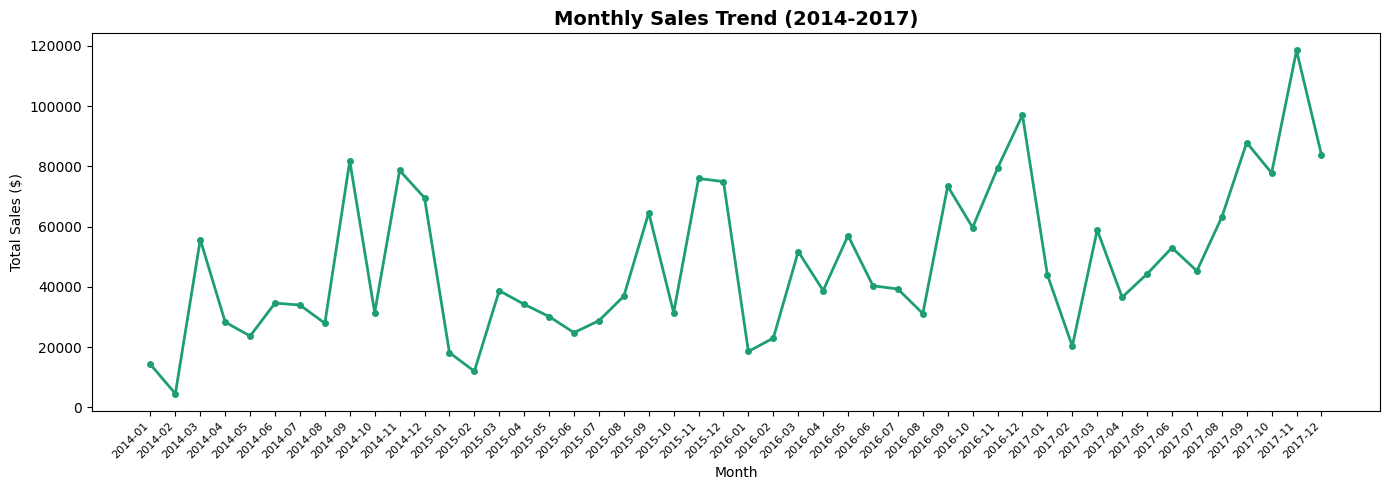

In [3]:
import matplotlib.pyplot as plt

# ── ANALYSIS 1: MONTHLY SALES TREND ───────────────────────
# Group all transactions by month and sum total sales per month

monthly_sales = df.groupby('Month-Year')['Sales'].sum().reset_index()
monthly_sales['Month-Year'] = monthly_sales['Month-Year'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Month-Year'], monthly_sales['Sales'],
         color='#1D9E75', linewidth=2, marker='o', markersize=4)
plt.xticks(rotation=45, ha='right', fontsize=8)         # rotate x labels for readability
plt.title('Monthly Sales Trend (2014-2017)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.tight_layout()               # auto-adjust spacing so nothing gets cut off
plt.savefig('monthly_sales_trend.png', dpi=150)         # save as image for README
plt.show()

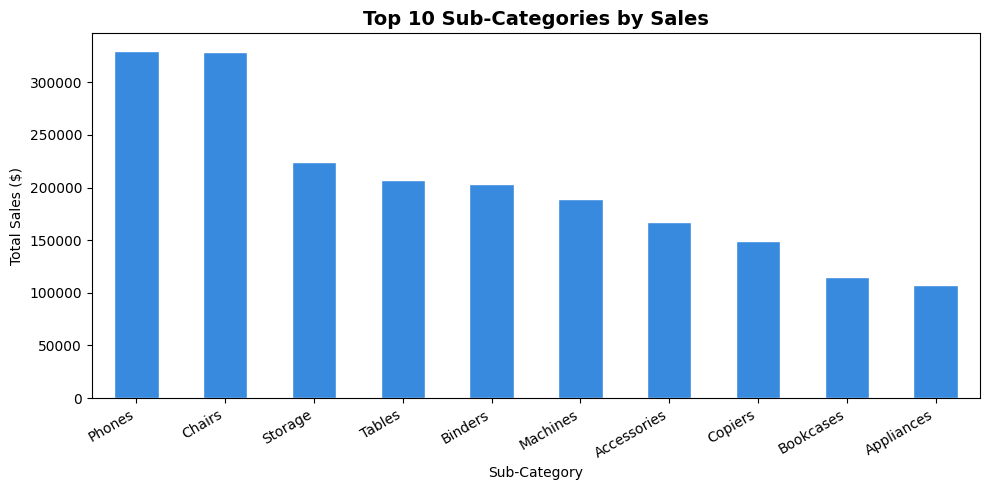

In [4]:
# ── ANALYSIS 2: TOP 10 SUB-CATEGORIES BY REVENUE ──────────
# Group by product sub-category, sum sales, sort descending, keep top 10


top_subcats = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_subcats.plot(kind='bar', color='#378ADD', edgecolor='white')
plt.title('Top 10 Sub-Categories by Sales', fontsize=14, fontweight='bold')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('top_subcategories.png', dpi=150)
plt.show()

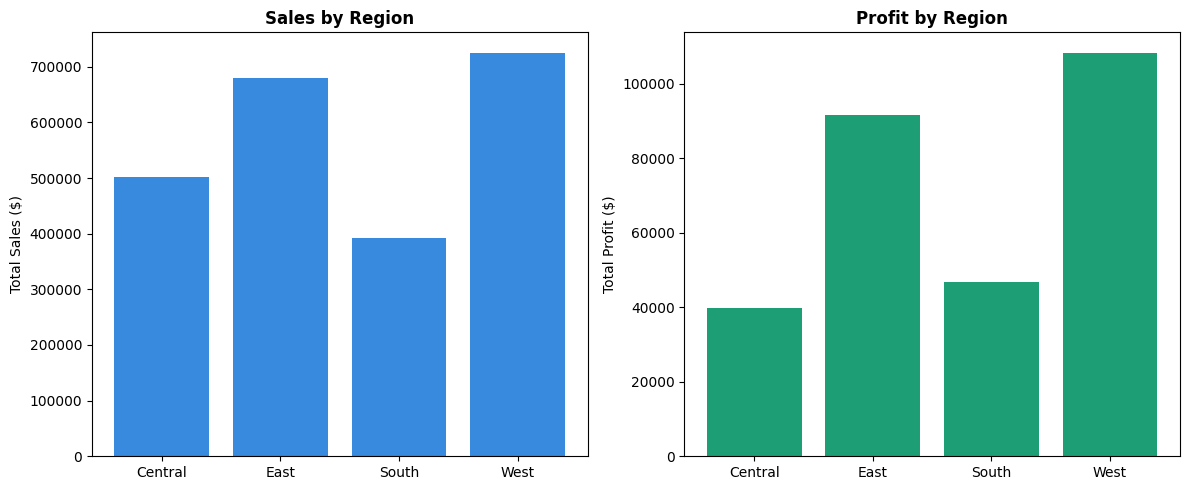

In [5]:
# ── ANALYSIS 3: REGIONAL SALES AND PROFIT ─────────────────
# Compare how each region performs on both sales and profit


region_sales = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))         # 1 row, 2 side-by-side charts
axes[0].bar(region_sales['Region'], region_sales['Sales'], color='#378ADD')
axes[0].set_title('Sales by Region', fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')

# Color profit bars green if positive, red if negative
axes[1].bar(region_sales['Region'], region_sales['Profit'],
            color=['#1D9E75' if x > 0 else '#E24B4A' for x in region_sales['Profit']])
axes[1].set_title('Profit by Region', fontweight='bold')
axes[1].set_ylabel('Total Profit ($)')

plt.tight_layout()
plt.savefig('region_performance.png', dpi=150)
plt.show()

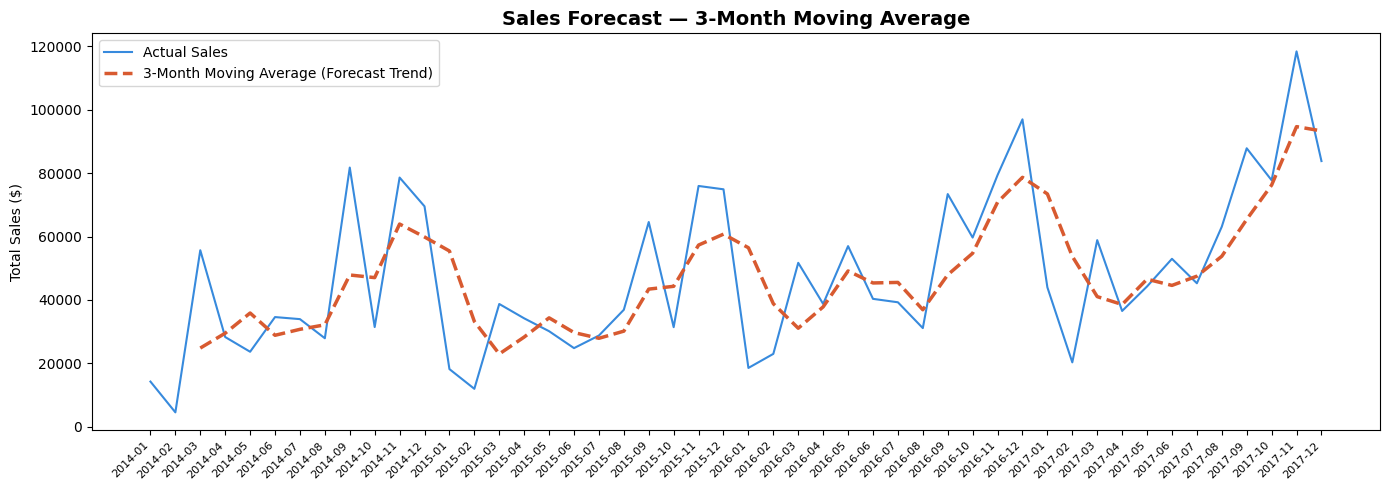

In [6]:
# ── ANALYSIS 4: SALES FORECAST ────────────────────────────
# Moving average smooths out month-to-month spikes to show the real trend
# window=3 means: average of current month + previous 2 months


monthly_sales['Sales_MA3'] = monthly_sales['Sales'].rolling(window=3).mean()

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Month-Year'], monthly_sales['Sales'],
         label='Actual Sales', color='#378ADD', linewidth=1.5)
plt.plot(monthly_sales['Month-Year'], monthly_sales['Sales_MA3'],
         label='3-Month Moving Average (Forecast Trend)', 
         color='#D85A30', linewidth=2.5, linestyle='--')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Sales Forecast — 3-Month Moving Average', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('sales_forecast.png', dpi=150)
plt.show()

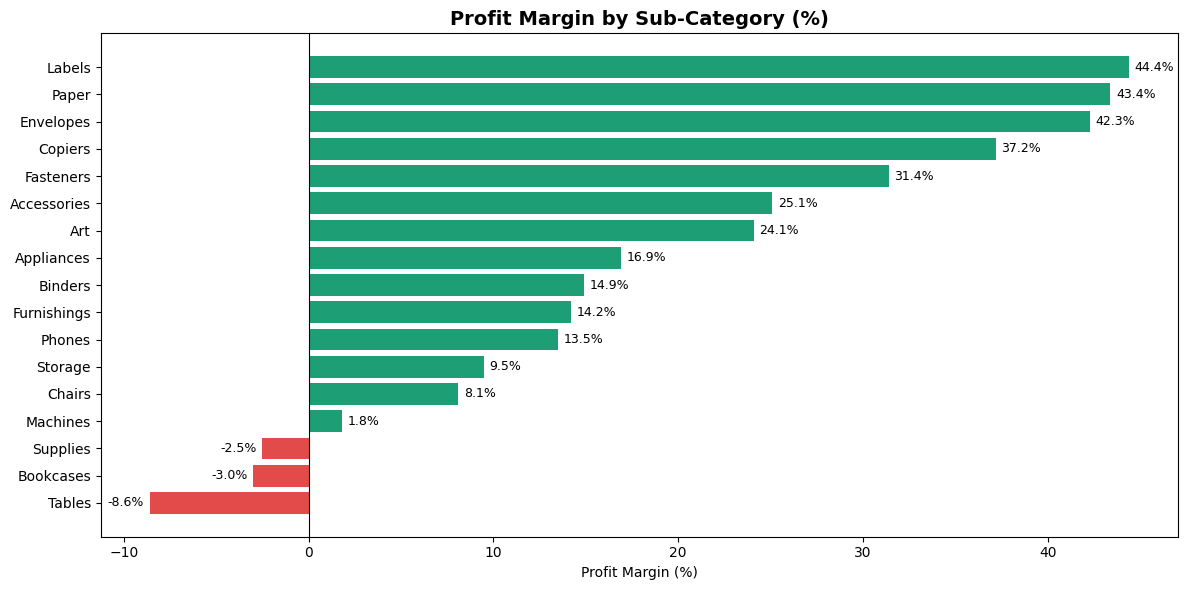

In [7]:
# ── ANALYSIS 5: PROFIT MARGIN BY SUB-CATEGORY ─────────────
# Profit margin = (profit / sales) × 100
# Reveals which products make money vs which are actually losing money


subcategory_profit = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

subcategory_profit['Profit_Margin'] = (
    subcategory_profit['Total_Profit'] / subcategory_profit['Total_Sales'] * 100
).round(1)

subcategory_profit = subcategory_profit.sort_values('Profit_Margin')

# Red bar = losing money, Green bar = making money
colors = ['#E24B4A' if x < 0 else '#1D9E75' for x in subcategory_profit['Profit_Margin']]

plt.figure(figsize=(12, 6))
bars = plt.barh(subcategory_profit['Sub-Category'], subcategory_profit['Profit_Margin'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)          # vertical line at 0 = break-even
plt.title('Profit Margin by Sub-Category (%)', fontsize=14, fontweight='bold')
plt.xlabel('Profit Margin (%)')

# add value labels
for bar, val in zip(bars, subcategory_profit['Profit_Margin']):
    plt.text(val + 0.3 if val >= 0 else val - 0.3, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('profit_margin_analysis.png', dpi=150)
plt.show()

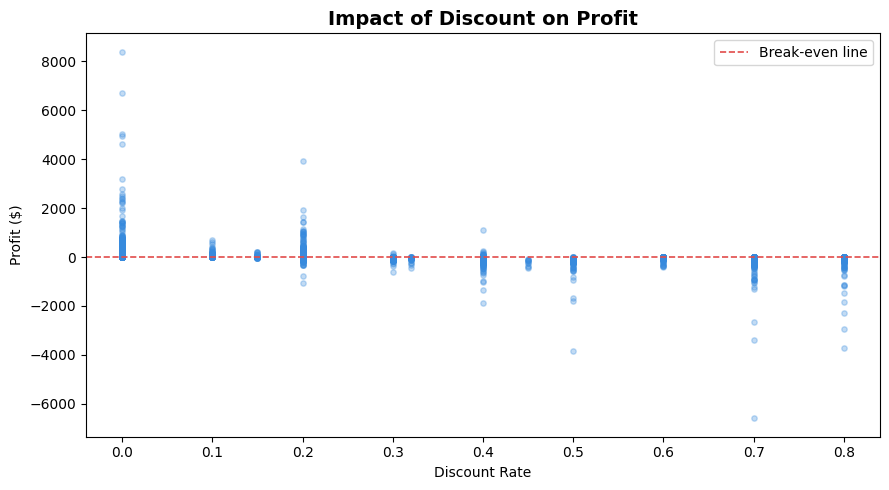

Correlation between Discount and Profit: -0.219
Interpretation: Negative correlation confirms higher discounts = lower profit


In [8]:
# ── ANALYSIS 6: DISCOUNT vs PROFIT ────────────────────────
# Each dot = one order. X = how much discount was given, Y = profit made
# If dots cluster below the red line at high discounts = discounting hurts profit


plt.figure(figsize=(9, 5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, color='#378ADD', s=15)
# alpha=0.3 makes dots semi-transparent so overlapping dots are visible

plt.axhline(y=0, color='#E24B4A', linewidth=1.2, linestyle='--', label='Break-even line')
plt.title('Impact of Discount on Profit', fontsize=14, fontweight='bold')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.legend()
plt.tight_layout()
plt.savefig('discount_vs_profit.png', dpi=150)
plt.show()

# Correlation coefficient: ranges from -1 to +1
# -0.219 = mild negative relationship (more discount = less profit)
correlation = df['Discount'].corr(df['Profit']).round(3)
print(f"Correlation between Discount and Profit: {correlation}")
print("Interpretation: Negative correlation confirms higher discounts = lower profit")

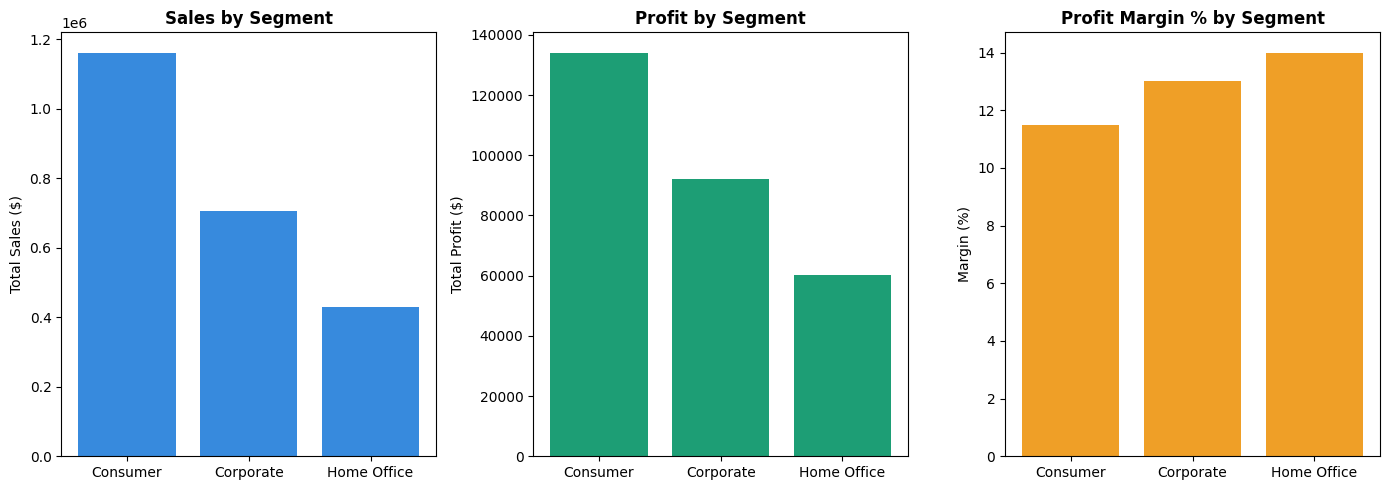

    Segment        Sales      Profit  Profit_Margin  Orders
   Consumer 1161401.3450 134119.2092           11.5    2586
  Corporate  706146.3668  91979.1340           13.0    1514
Home Office  429653.1485  60298.6785           14.0     909


In [9]:
# ── ANALYSIS 7: CUSTOMER SEGMENT BREAKDOWN ────────────────
# Compare Consumer, Corporate, Home Office on sales, profit and margin


segment = df.groupby('Segment').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')          # count unique orders per segment
).reset_index()

# Profit margin tells us which segment is most EFFICIENT, not just biggest
segment['Profit_Margin'] = (segment['Profit'] / segment['Sales'] * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].bar(segment['Segment'], segment['Sales'], color='#378ADD')
axes[0].set_title('Sales by Segment', fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')

axes[1].bar(segment['Segment'], segment['Profit'], color='#1D9E75')
axes[1].set_title('Profit by Segment', fontweight='bold')
axes[1].set_ylabel('Total Profit ($)')

axes[2].bar(segment['Segment'], segment['Profit_Margin'], color='#EF9F27')
axes[2].set_title('Profit Margin % by Segment', fontweight='bold')
axes[2].set_ylabel('Margin (%)')

plt.tight_layout()
plt.savefig('customer_segments.png', dpi=150)
plt.show()
print(segment[['Segment', 'Sales', 'Profit', 'Profit_Margin', 'Orders']].to_string(index=False))

In [10]:
import pandas as pd

# --- Top 3 Sub-Categories ---
top3 = df.groupby('Sub-Category')['Sales'].sum().nlargest(3)
total_sales = df['Sales'].sum()

top3_sales = top3.sum()
top3_share = (top3_sales / total_sales) * 100

print("TOP 3 SUB-CATEGORIES")
print("---------------------")
print(f"Categories: {list(top3.index)}")
print(f"Combined Sales: ${top3_sales:,.0f}")
print(f"Revenue Share: {top3_share:.1f}%\n")


# --- Furniture Discount Impact ---
furniture = df[df['Category'] == 'Furniture']
high_disc = furniture[furniture['Discount'] >= 0.2]

total_orders = len(high_disc)
loss_orders = (high_disc['Profit'] < 0).sum()

loss_rate = (loss_orders / total_orders * 100) if total_orders > 0 else 0

print("FURNITURE DISCOUNT IMPACT")
print("--------------------------")
print(f"Orders with >20% discount: {total_orders}")
print(f"Loss-making orders: {loss_orders}")
print(f"Loss Rate: {loss_rate:.1f}%\n")


# --- Regional Margins ---
region = df.groupby('Region').agg({'Sales': 'sum', 'Profit': 'sum'})
region['Margin (%)'] = (region['Profit'] / region['Sales'] * 100).round(1)

print("REGIONAL PROFIT MARGINS")
print("------------------------")
print(region['Margin (%)'], "\n")


# --- Machines Analysis ---
machines = df[df['Sub-Category'] == 'Machines']

sales = machines['Sales'].sum()
profit = machines['Profit'].sum()
margin = (profit / sales * 100) if sales > 0 else 0

print("MACHINES PERFORMANCE")
print("---------------------")
print(f"Sales: ${sales:,.0f}")
print(f"Profit: ${profit:,.0f}")
print(f"Margin: {margin:.1f}%")

TOP 3 SUB-CATEGORIES
---------------------
Categories: ['Phones', 'Chairs', 'Storage']
Combined Sales: $882,300
Revenue Share: 38.4%

FURNITURE DISCOUNT IMPACT
--------------------------
Orders with >20% discount: 1157
Loss-making orders: 693
Loss Rate: 59.9%

REGIONAL PROFIT MARGINS
------------------------
Region
Central     7.9
East       13.5
South      11.9
West       14.9
Name: Margin (%), dtype: float64 

MACHINES PERFORMANCE
---------------------
Sales: $189,239
Profit: $3,385
Margin: 1.8%
